In [15]:
//import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
# Step 1: Reading the external dataset
df = pd.read_csv('players_22.csv')
df

C:\Users\bashi\AppData\Local\Temp\ipykernel_1204\1538296327.py:2: DtypeWarning: Columns (25,108) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('players_22.csv')


,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,261962,https://sofifa.com/player/261962/defu-song/220002,Song Defu,宋德福,CDM,47,52,70000.0,1000.0,22,...,46+2,46+2,46+2,48+2,15+2,https://cdn.sofifa.net/players/261/962/22_120.png,https://cdn.sofifa.net/teams/112541/60.png,https://cdn.sofifa.net/flags/cn.png,NaN,https://cdn.sofifa.net/flags/cn.png
19235,262040,https://sofifa.com/player/262040/caoimhin-port...,C. Porter,Caoimhin Porter,CM,47,59,110000.0,500.0,19,...,44+2,44+2,44+2,48+2,14+2,https://cdn.sofifa.net/players/262/040/22_120.png,https://cdn.sofifa.net/teams/445/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png
19236,262760,https://sofifa.com/player/262760/nathan-logue/...,N. Logue,Nathan Logue-Cunningham,CM,47,55,100000.0,500.0,21,...,45+2,45+2,45+2,47+2,12+2,https://cdn.sofifa.net/players/262/760/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png
19237,262820,https://sofifa.com/player/262820/luke-rudden/2...,L. Rudden,Luke Rudden,ST,47,60,110000.0,500.0,19,...,26+2,26+2,26+2,32+2,15+2,https://cdn.sofifa.net/players/262/820/22_120.png,https://cdn.sofifa.net/teams/111131/60.png,https://cdn.sofifa.net/flags/ie.png,NaN,https://cdn.sofifa.net/flags/ie.png


In [17]:
# Step 2: Descriptive Statistics
print("Dataset Overview:")
print(df.info())
print("\nDescriptive Statistics (Numerical):")
print(df.describe())
print("\nDescriptive Statistics (Categorical):")
print(df.describe(include=['object']))

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19239 entries, 0 to 19238
Columns: 110 entries, sofifa_id to nation_flag_url
dtypes: float64(16), int64(44), object(50)
memory usage: 16.1+ MB
None

Descriptive Statistics (Numerical):
           sofifa_id       overall     potential     value_eur       wage_eur  \
count   19239.000000  19239.000000  19239.000000  1.916500e+04   19178.000000   
mean   231468.086959     65.772182     71.079370  2.850452e+06    9017.989363   
std     27039.717497      6.880232      6.086213  7.613700e+06   19470.176724   
min        41.000000     47.000000     49.000000  9.000000e+03     500.000000   
25%    214413.500000     61.000000     67.000000  4.750000e+05    1000.000000   
50%    236543.000000     66.000000     71.000000  9.750000e+05    3000.000000   
75%    253532.500000     70.000000     75.000000  2.000000e+06    8000.000000   
max    264640.000000     93.000000     95.000000  1.940000e+08  350000.000000   

                a

In [18]:
df.head()

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png


In [19]:
# Step 3: Handling Missing Values
missing_values = df.isnull().sum()
print("\nMissing Values in Dataset:")
print(missing_values[missing_values > 0])

# Dropping columns with excessive missing values
df = df.dropna(thresh=len(df) * 0.6, axis=1)

# Filling remaining missing values with mean or mode
df = df.fillna({col: df[col].mean() if df[col].dtype != 'object' else df[col].mode()[0] for col in df.columns})


Missing Values in Dataset:
value_eur                       74
wage_eur                        61
club_team_id                    61
club_name                       61
league_name                     61
league_level                    61
club_position                   61
club_jersey_number              61
club_loaned_from             18137
club_joined                   1163
club_contract_valid_until       61
nation_team_id               18480
nation_position              18480
nation_jersey_number         18480
release_clause_eur            1176
player_tags                  17798
player_traits                 9841
pace                          2132
shooting                      2132
passing                       2132
dribbling                     2132
defending                     2132
physic                        2132
goalkeeping_speed            17107
club_logo_url                   61
club_flag_url                   61
nation_logo_url              18480
dtype: int64


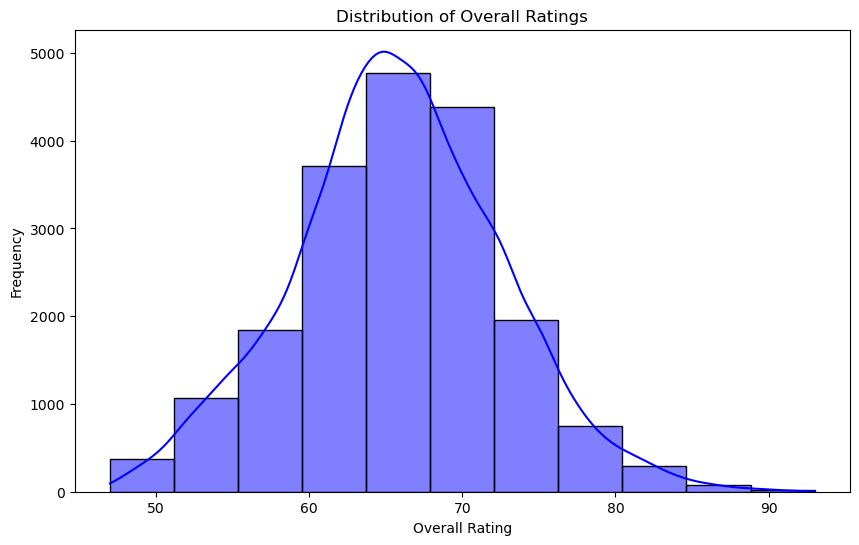

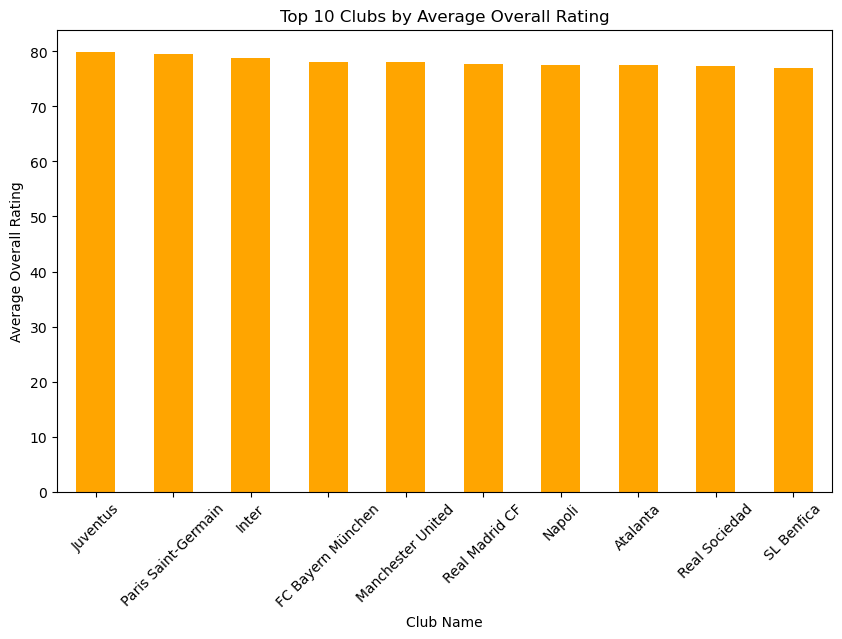

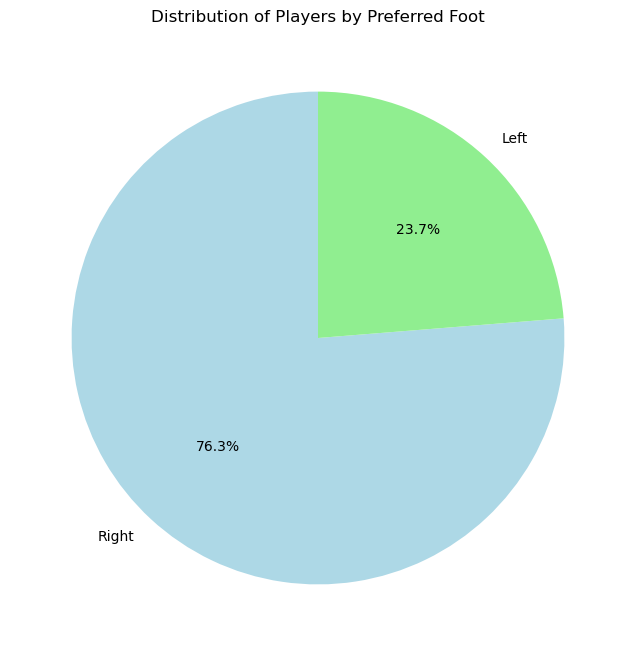

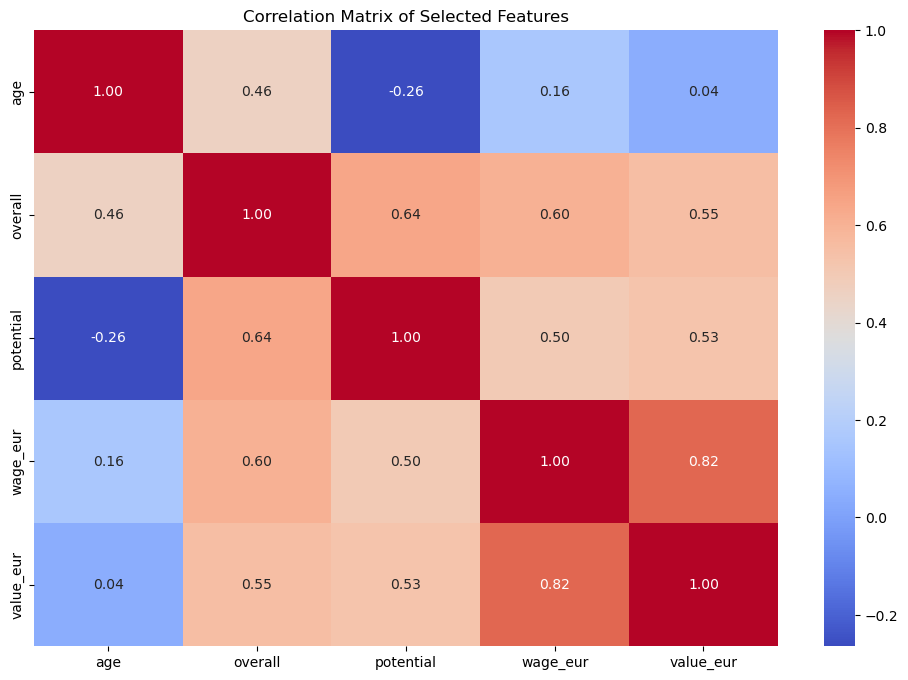

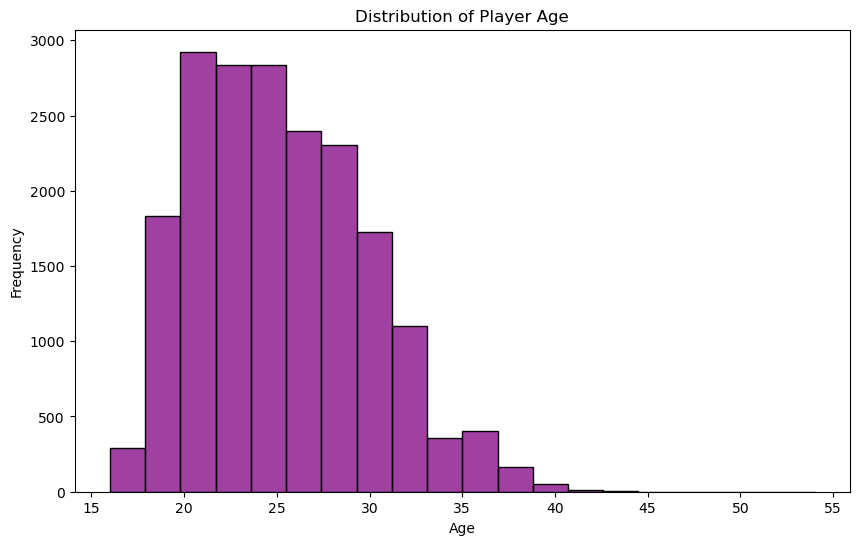

In [20]:
# # Step 4: Visualizations
# # Example histogram of overall ratings
plt.figure(figsize=(10, 6))
sns.histplot(df['overall'], kde=True, bins=11, color='blue')
plt.title('Distribution of Overall Ratings')
plt.xlabel('Overall Rating')
plt.ylabel('Frequency')
plt.show()


# # Bar chart: Top 10 Clubs by Average Overall Rating
club_avg_overall = df.groupby('club_name')['overall'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
club_avg_overall.plot(kind='bar', color='orange')
plt.title('Top 10 Clubs by Average Overall Rating')
plt.xlabel('Club Name')
plt.ylabel('Average Overall Rating')
plt.xticks(rotation=45)
plt.show()


# # Pie chart: Distribution of Players by Preferred Foot
foot_distribution = df['preferred_foot'].value_counts()
plt.figure(figsize=(8, 8))
foot_distribution.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen'])
plt.title('Distribution of Players by Preferred Foot')
plt.ylabel('')
plt.show()



# # Correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[['age', 'overall', 'potential', 'wage_eur', 'value_eur']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Selected Features')
plt.show()



# # Histogram: Distribution of Player Age
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], kde=False, bins=20, color='purple')
plt.title('Distribution of Player Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [21]:
# Step 5: Unique Values in Categorical Variables
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"Unique values in {col}: {df[col].nunique()}")

Unique values in player_url: 19239
Unique values in short_name: 18145
Unique values in long_name: 19219
Unique values in player_positions: 674
Unique values in dob: 6312
Unique values in club_name: 701
Unique values in league_name: 55
Unique values in club_position: 29
Unique values in club_joined: 1845
Unique values in nationality_name: 163
Unique values in preferred_foot: 2
Unique values in work_rate: 9
Unique values in body_type: 10
Unique values in real_face: 2
Unique values in ls: 228
Unique values in st: 228
Unique values in rs: 228
Unique values in lw: 138
Unique values in lf: 132
Unique values in cf: 132
Unique values in rf: 132
Unique values in rw: 138
Unique values in lam: 252
Unique values in cam: 252
Unique values in ram: 252
Unique values in lm: 235
Unique values in lcm: 212
Unique values in cm: 212
Unique values in rcm: 212
Unique values in rm: 235
Unique values in lwb: 196
Unique values in ldm: 239
Unique values in cdm: 239
Unique values in rdm: 239
Unique values in rwb:

In [22]:
# Step 6: Subset Data
subset = df[(df['age'] < 25) & (df['overall'] > 80)]
print("\nSubset Descriptive Statistics:")
print(subset.describe())


Subset Descriptive Statistics:
           sofifa_id    overall  potential     value_eur       wage_eur  \
count      74.000000  74.000000  74.000000  7.400000e+01      74.000000   
mean   233131.067568  82.824324  87.824324  5.867568e+07   89175.675676   
std      7282.965099   2.109068   2.571488  2.837463e+07   43582.501864   
min    216393.000000  81.000000  81.000000  2.700000e+07   19000.000000   
25%    229886.500000  81.000000  86.000000  4.150000e+07   57500.000000   
50%    232572.000000  82.000000  87.500000  4.900000e+07   80000.000000   
75%    237220.250000  83.750000  89.000000  6.387500e+07  120000.000000   
max    251854.000000  91.000000  95.000000  1.940000e+08  230000.000000   

             age   height_cm  weight_kg   club_team_id  league_level  ...  \
count  74.000000   74.000000  74.000000      74.000000          74.0  ...   
mean   22.756757  181.013514  74.810811    7730.162162           1.0  ...   
std     1.311809    5.839153   6.686063   28308.141223       

In [23]:
# Step 7: Pivot Tables
pivot_table = df.pivot_table(values='overall', index='club_name', aggfunc='mean').sort_values(by='overall', ascending=False)
print("\nPivot Table of Average Overall Ratings by Club:")
print(pivot_table.head())


Pivot Table of Average Overall Ratings by Club:
                       overall
club_name                     
Juventus             79.961538
Paris Saint-Germain  79.454545
Inter                78.857143
FC Bayern München    78.071429
Manchester United    78.000000


In [24]:
# Step 8: Linear Regression (Improved)
# Step 1: Set 'overall' as the target variable
target = 'overall'
features = ['age', 'potential', 'wage_eur', 'international_reputation']  # Define feature columns

# Ensure all required features are numeric and clean the dataset
df['wage_eur'] = pd.to_numeric(df['wage_eur'], errors='coerce')  # Ensure numeric values
clean_df = df.dropna(subset=[target] + features).fillna(0)

# Feature matrix (X) and target vector (y)
X = clean_df[features]
y = clean_df[target]

In [25]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [26]:
# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [27]:
X_train

,age,potential,wage_eur,international_reputation
4344,26,71,5000.0,1
11894,23,70,2000.0,1
18036,20,65,500.0,1
10366,35,65,1000.0,1
18292,20,66,500.0,1
...,...,...,...,...
10955,19,79,3000.0,1
17289,17,73,600.0,1
5192,22,79,44000.0,1
12172,23,70,3000.0,1


In [28]:
X_test

,age,potential,wage_eur,international_reputation
3339,28,74,8000.0,1
11183,29,64,2000.0,1
3645,28,72,18000.0,1
8063,23,73,3000.0,1
12536,24,68,3000.0,1
...,...,...,...,...
13205,18,80,950.0,1
16322,19,73,500.0,1
8018,31,67,11000.0,1
8067,24,75,5000.0,1


In [29]:
y_train

4344     71
11894    64
18036    55
10366    65
18292    54
         ..
10955    65
17289    57
5192     70
12172    64
235      82
Name: overall, Length: 15391, dtype: int64

In [30]:
y_test

3339     72
11183    64
3645     72
8063     67
12536    63
         ..
13205    63
16322    59
8018     67
8067     67
16270    59
Name: overall, Length: 3848, dtype: int64

In [31]:
# Building the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [32]:
# Step 9: Make Predictions for New Data
# Example for Linear Regression
# Example: Predicting 'Overall' for a player
new_player_data = pd.DataFrame([[25, 85, 200000, 4]], columns=features)  # Example input: Age, Potential, Wage (EUR), International Reputation
predicted_overall = linear_model.predict(new_player_data)
print(f"\nPredicted Overall Rating for New Player: {predicted_overall[0]:.2f}")


Predicted Overall Rating for New Player: 85.26


In [33]:
# Model Evaluation
y_pred = model.predict(X_test)
print("\nLinear Regression Results:")
print(f"R^2 Score: {r2_score(y_test, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")


Linear Regression Results:
R^2 Score: 0.8534623893708189
Mean Squared Error: 7.027208333655991
